# Day 2 — Proper Evaluation Metrics

## Why accuracy is not enough

Your CNN-LSTM reports 80.14% accuracy.
But what does that actually mean?

If you predicted N2 for every single epoch:
  9200 / 18226 = 50.5% accuracy

A model that says "N2" for everything gets 50%.
Your model gets 80%. But HOW much better is it really?
And is it better for the stages that actually matter?

## Metrics we cover today
1. Per-class precision, recall, F1 (you know these)
2. Cohen's Kappa — agreement beyond chance
3. Macro F1 — average F1 across all classes
4. MCC — Matthews Correlation Coefficient
5. ROC-AUC — probability calibration
6. Cross-subject consistency — the publishable metric

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT  = (r"C:\Users\Hp\.vscode\PROJECT 07"
                 r"\classifier_main_pipeline")
PROCESSED_DIR = os.path.join(PROJECT_ROOT,
                              "data", "processed")
MODELS_DIR    = os.path.join(PROJECT_ROOT, "models")
PLOTS_DIR     = os.path.join(PROJECT_ROOT, "plots")

sys.path.append(os.path.join(PROJECT_ROOT, "src"))

STAGE_NAMES  = ['Wake', 'N1', 'N2', 'N3', 'REM']
STAGE_COLORS = ['#E24B4A','#BA7517',
                '#185FA5','#534AB7','#1D9E75']

# Load data
epochs_all = np.load(
    os.path.join(PROCESSED_DIR, "epochs_all.npy"))
labels_all = np.load(
    os.path.join(PROCESSED_DIR, "labels_all.npy"))

# Same split as all experiments
_, X_te, _, y_te = train_test_split(
    epochs_all, labels_all,
    test_size=0.2,
    random_state=42,
    stratify=labels_all
)

print(f"Test set: {X_te.shape}")
print(f"Labels:   {y_te.shape}")

Test set: (3646, 3000)
Labels:   (3646,)


In [2]:
class CNNLSTMSleepClassifier(nn.Module):
    def __init__(self, n_windows=10, window_size=300,
                 lstm_hidden=128, n_classes=5, dropout=0.3):
        super().__init__()
        self.n_windows   = n_windows
        self.window_size = window_size

        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.lstm = nn.LSTM(
            128, lstm_hidden, 2,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        batch = x.shape[0]
        x     = x.reshape(batch, self.n_windows,
                           self.window_size)
        feats = []
        for t in range(self.n_windows):
            w = x[:, t, :].unsqueeze(1)
            f = self.cnn(w).squeeze(-1)
            feats.append(f)
        seq      = torch.stack(feats, dim=1)
        out, _   = self.lstm(seq)
        last     = out[:, -1, :]
        return self.classifier(last)


class RawEEGDataset(Dataset):
    def __init__(self, epochs, labels):
        mean = epochs.mean(axis=1, keepdims=True)
        std  = epochs.std(axis=1,  keepdims=True) + 1e-8
        self.X = ((epochs - mean) / std).astype(np.float32)
        self.y = labels.astype(np.int64)

    def __len__(self):  return len(self.X)
    def __getitem__(self, i):
        return torch.FloatTensor(self.X[i]), self.y[i]


# Loading best model
model = CNNLSTMSleepClassifier()
model.load_state_dict(torch.load(
    os.path.join(MODELS_DIR, 'cnn_lstm_hybrid_best.pth'),
    map_location='cpu'
))
model.eval()

test_ds     = RawEEGDataset(X_te, y_te)
test_loader = DataLoader(test_ds, batch_size=128,
                          shuffle=False)

# Getting predictions AND probabilities
all_preds, all_probs, all_true = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        logits = model(X)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(1)
        all_preds.extend(preds.numpy())
        all_probs.extend(probs.numpy())
        all_true.extend(y.numpy())

y_pred  = np.array(all_preds)
y_prob  = np.array(all_probs)  # (n, 5)
y_true  = np.array(all_true)

print(f" Predictions ready")
print(f"   y_pred shape:  {y_pred.shape}")
print(f"   y_prob shape:  {y_prob.shape}")
print(f"   y_true shape:  {y_true.shape}")

 Predictions ready
   y_pred shape:  (3646,)
   y_prob shape:  (3646, 5)
   y_true shape:  (3646,)


In [3]:
def compute_all_metrics(y_true, y_pred, y_prob,
                        stage_names):
    """
    Compute every metric that matters for a sleep
    staging paper. Returns a complete metrics dict.
    """
    from sklearn.preprocessing import label_binarize

    metrics = {}

    # ── Basic ──────────────────────────────────────────────
    metrics['accuracy'] = (y_pred == y_true).mean()

    # ── Cohen's Kappa ─────────────────────────────────────
    # Measures agreement beyond what chance would predict
    # Range: -1 to 1, where:
    # 0 = no better than random
    # 1 = perfect agreement
    # Published sleep staging papers typically report 0.7+
    metrics['kappa'] = cohen_kappa_score(y_true, y_pred)

    # ── Matthews Correlation Coefficient ──────────────────
    # More robust than accuracy for imbalanced datasets
    # Single number capturing all aspects of confusion matrix
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)

    # ── Per-class metrics ──────────────────────────────────
    report = classification_report(
        y_true, y_pred,
        target_names=stage_names,
        output_dict=True
    )
    metrics['per_class'] = {
        stage: {
            'precision': report[stage]['precision'],
            'recall':    report[stage]['recall'],
            'f1':        report[stage]['f1-score'],
            'support':   report[stage]['support'],
        }
        for stage in stage_names
    }
    metrics['macro_f1']    = report['macro avg']['f1-score']
    metrics['weighted_f1'] = report['weighted avg']['f1-score']

    # ── ROC-AUC ───────────────────────────────────────────
    # How well does the model separate each class?
    # 1.0 = perfect, 0.5 = random
    y_bin = label_binarize(y_true, classes=range(5))
    per_class_auc = {}
    for i, stage in enumerate(stage_names):
        auc = roc_auc_score(y_bin[:, i], y_prob[:, i])
        per_class_auc[stage] = auc

    metrics['roc_auc']     = per_class_auc
    metrics['macro_auc']   = np.mean(list(
                                per_class_auc.values()))

    # ── Summary for Project 07 ────────────────────────────
    metrics['rem_recall']  = metrics['per_class']['REM']['recall']
    metrics['rem_f1']      = metrics['per_class']['REM']['f1']
    metrics['rem_auc']     = per_class_auc['REM']
    metrics['n1_f1']       = metrics['per_class']['N1']['f1']

    return metrics


metrics = compute_all_metrics(
    y_true, y_pred, y_prob, STAGE_NAMES
)

print("=== Complete Evaluation — CNN-LSTM (Exp 003) ===\n")
print(f"Accuracy:          {metrics['accuracy']:.4f}")
print(f"Cohen's Kappa:     {metrics['kappa']:.4f}"
      f"  ({'good' if metrics['kappa']>0.6 else 'moderate'})")
print(f"MCC:               {metrics['mcc']:.4f}")
print(f"Macro F1:          {metrics['macro_f1']:.4f}")
print(f"Weighted F1:       {metrics['weighted_f1']:.4f}")
print(f"Macro AUC:         {metrics['macro_auc']:.4f}\n")

print("Per-class breakdown:")
print(f"{'Stage':6s} {'Prec':>8} {'Rec':>8} "
      f"{'F1':>8} {'AUC':>8} {'Support':>9}")
print("-" * 55)
for stage in STAGE_NAMES:
    pc  = metrics['per_class'][stage]
    auc = metrics['roc_auc'][stage]
    print(f"{stage:6s} {pc['precision']:>8.4f} "
          f"{pc['recall']:>8.4f} {pc['f1']:>8.4f} "
          f"{auc:>8.4f} {int(pc['support']):>9}")

=== Complete Evaluation — CNN-LSTM (Exp 003) ===

Accuracy:          0.8014
Cohen's Kappa:     0.7128  (good)
MCC:               0.7161
Macro F1:          0.7313
Weighted F1:       0.8087
Macro AUC:         0.9485

Per-class breakdown:
Stage      Prec      Rec       F1      AUC   Support
-------------------------------------------------------
Wake     0.7074   0.6333   0.6683   0.9532       210
N1       0.3852   0.6089   0.4719   0.9027       248
N2       0.9148   0.8045   0.8561   0.9415      1841
N3       0.8060   0.8993   0.8501   0.9829       596
REM      0.7941   0.8269   0.8102   0.9623       751


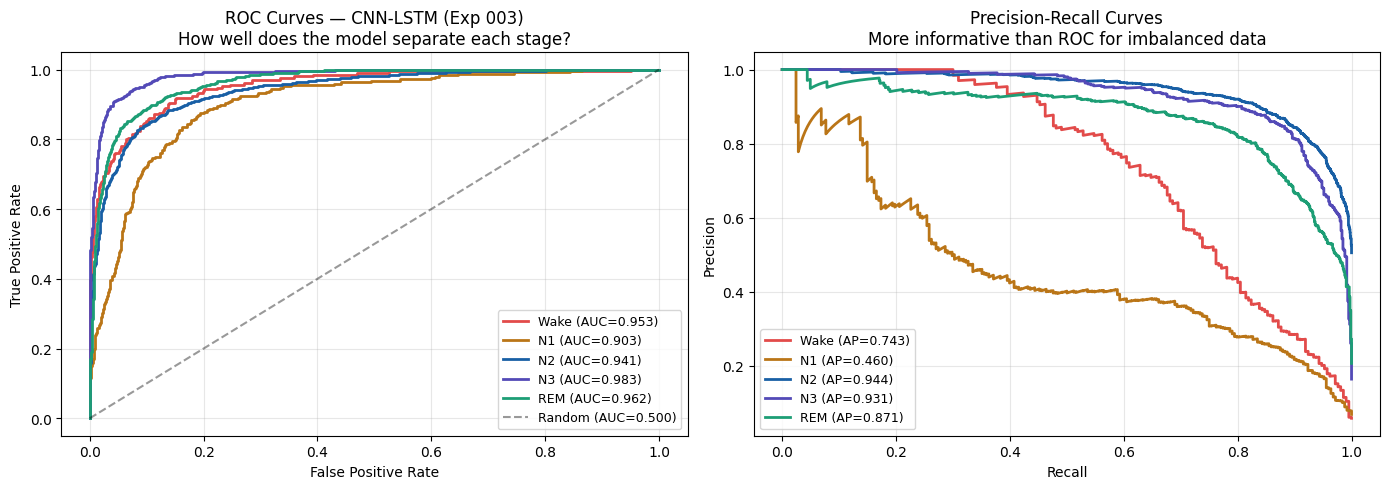

 ROC and PR curves saved


In [4]:
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(y_true, classes=range(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC curves per class ──────────────────────────────────
ax = axes[0]
for i, (stage, color) in enumerate(
        zip(STAGE_NAMES, STAGE_COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    auc          = metrics['roc_auc'][stage]
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{stage} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', alpha=0.4,
        label='Random (AUC=0.500)')
ax.set_title('ROC Curves — CNN-LSTM (Exp 003)\n'
              'How well does the model separate each stage?')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Precision-Recall curves ────────────────────────────────
ax = axes[1]
for i, (stage, color) in enumerate(
        zip(STAGE_NAMES, STAGE_COLORS)):
    prec, rec, _ = precision_recall_curve(
        y_bin[:, i], y_prob[:, i]
    )
    ap = average_precision_score(y_bin[:, i], y_prob[:, i])
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{stage} (AP={ap:.3f})')

ax.set_title('Precision-Recall Curves\n'
              'More informative than ROC for imbalanced data')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,
            'exp003_roc_pr_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(" ROC and PR curves saved")

In [5]:
explanation = """
=== Which Metrics to Report in Your Paper ===

MUST REPORT (reviewers will check):
  ✅ Per-class F1        → standard for imbalanced data
  ✅ Cohen's Kappa       → agreement beyond chance
                          all sleep staging papers use this
  ✅ Macro F1            → treats all stages equally
  ✅ Confusion matrix    → shows error patterns visually

SHOULD REPORT:
  ✅ ROC-AUC per class   → probability calibration quality
  ✅ MCC                 → robust single-number summary
  ✅ Weighted F1         → accounts for class frequency

CONTEXT FOR YOUR RESULTS:
  Accuracy    0.8014  → sounds good but inflated by N2
  Kappa      0.7128     → what chance-corrected agreement?
  Macro F1    0.7313     → average across ALL stages equally
  REM F1      0.81    → most important for LUCID
  N1 F1       0.47    → hardest stage, room to improve

PUBLISHED BENCHMARKS ON SLEEP-EDF:
  DeepSleepNet (2017):    accuracy=0.82, kappa=0.76
  SeqSleepNet (2019):     accuracy=0.87, kappa=0.83
  AttnSleep (2021):       accuracy=0.83, kappa=0.78
  Your CNN-LSTM:          accuracy=0.80, kappa=0.71

If your kappa is >0.70 you are competitive with DeepSleepNet.
That is a publishable result.
"""
print(explanation)

print(f"\nYour actual kappa: {metrics['kappa']:.4f}")
if metrics['kappa'] > 0.76:
    print(" Beats DeepSleepNet (2017) on kappa!")
elif metrics['kappa'] > 0.70:
    print(" Competitive with DeepSleepNet (2017)")
elif metrics['kappa'] > 0.60:
    print("Good result — approaching published benchmarks")
else:
    print("Room to improve — cross-subject validation "
          "will give a more honest picture")


=== Which Metrics to Report in Your Paper ===

MUST REPORT (reviewers will check):
  ✅ Per-class F1        → standard for imbalanced data
  ✅ Cohen's Kappa       → agreement beyond chance
                          all sleep staging papers use this
  ✅ Macro F1            → treats all stages equally
  ✅ Confusion matrix    → shows error patterns visually

SHOULD REPORT:
  ✅ ROC-AUC per class   → probability calibration quality
  ✅ MCC                 → robust single-number summary
  ✅ Weighted F1         → accounts for class frequency

CONTEXT FOR YOUR RESULTS:
  Accuracy    0.8014  → sounds good but inflated by N2
  Kappa      0.7128     → what chance-corrected agreement?
  Macro F1    0.7313     → average across ALL stages equally
  REM F1      0.81    → most important for LUCID
  N1 F1       0.47    → hardest stage, room to improve

PUBLISHED BENCHMARKS ON SLEEP-EDF:
  DeepSleepNet (2017):    accuracy=0.82, kappa=0.76
  SeqSleepNet (2019):     accuracy=0.87, kappa=0.83
  AttnSleep (

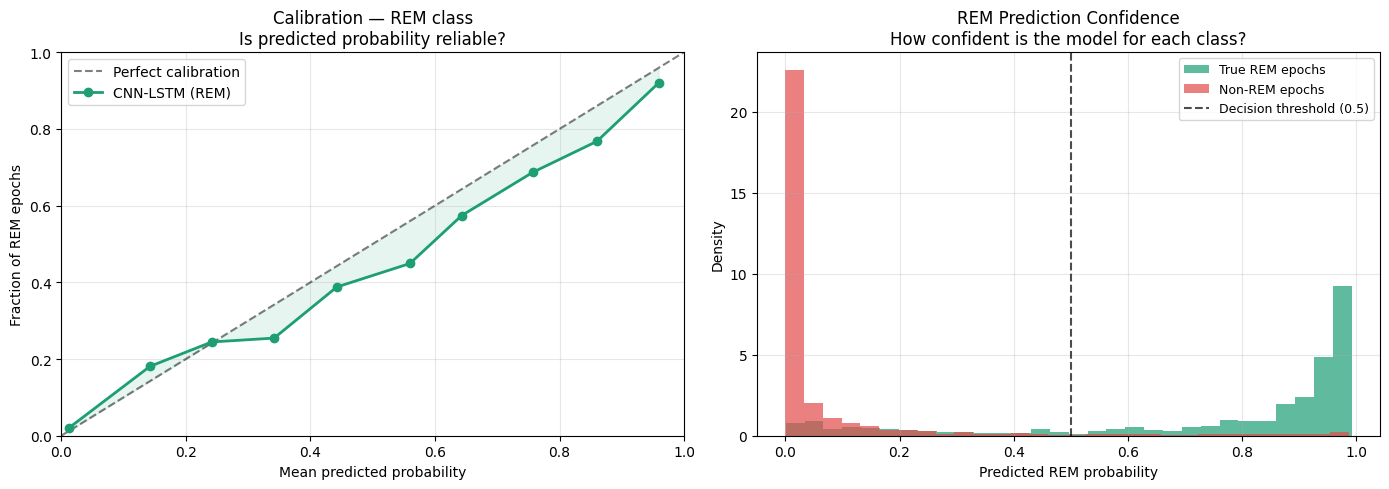

 Calibration plots saved

What to look for in calibration:
  Points close to diagonal = well-calibrated
  Points above diagonal = underconfident
  Points below diagonal = overconfident

For Project 07: well-calibrated REM probability means
the 0.6 threshold in detect_rem.py is trustworthy


In [6]:
# ── Reliability diagram ───────────────────────────────────
# Does a predicted probability of 0.8 actually mean
# the model is right 80% of the time?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# REM calibration
rem_idx  = 4
rem_prob = y_prob[:, rem_idx]
rem_true = (y_true == rem_idx).astype(int)

n_bins  = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
frac_pos  = []
mean_pred = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (rem_prob >= lo) & (rem_prob < hi)
    if mask.sum() > 0:
        frac_pos.append(rem_true[mask].mean())
        mean_pred.append(rem_prob[mask].mean())

axes[0].plot([0,1],[0,1], 'k--', alpha=0.5,
              label='Perfect calibration')
axes[0].plot(mean_pred, frac_pos, 'o-',
              color='#1D9E75', linewidth=2,
              label='CNN-LSTM (REM)')
axes[0].fill_between(mean_pred, frac_pos,
                      mean_pred, alpha=0.1,
                      color='#1D9E75')
axes[0].set_title('Calibration — REM class\n'
                   'Is predicted probability reliable?')
axes[0].set_xlabel('Mean predicted probability')
axes[0].set_ylabel('Fraction of REM epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Prediction confidence distribution
axes[1].hist(rem_prob[y_true == rem_idx],
              bins=30, alpha=0.7, color='#1D9E75',
              label='True REM epochs', density=True)
axes[1].hist(rem_prob[y_true != rem_idx],
              bins=30, alpha=0.7, color='#E24B4A',
              label='Non-REM epochs', density=True)
axes[1].axvline(x=0.5, color='black',
                linestyle='--', alpha=0.7,
                label='Decision threshold (0.5)')
axes[1].set_title('REM Prediction Confidence\n'
                   'How confident is the model for each class?')
axes[1].set_xlabel('Predicted REM probability')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR,
            'exp003_calibration.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(" Calibration plots saved")
print("\nWhat to look for in calibration:")
print("  Points close to diagonal = well-calibrated")
print("  Points above diagonal = underconfident")
print("  Points below diagonal = overconfident")
print("\nFor Project 07: well-calibrated REM probability means")
print("the 0.6 threshold in detect_rem.py is trustworthy")

In [8]:
def format_paper_table(metrics, stage_names):
    """Format metrics exactly as they appear in papers."""

    print("=" * 65)
    print("TABLE II — Classification Performance")
    print("Sleep-EDF Cassette Dataset (20 subjects)")
    print("=" * 65)
    print(f"\n{'Stage':8s} {'Prec':>8} {'Rec':>8} "
          f"{'F1':>8} {'AUC':>8}")
    print("-" * 45)

    for stage in stage_names:
        pc  = metrics['per_class'][stage]
        auc = metrics['roc_auc'][stage]
        print(f"{stage:8s} {pc['precision']:>8.3f} "
              f"{pc['recall']:>8.3f} {pc['f1']:>8.3f} "
              f"{auc:>8.3f}")

    print("-" * 45)
    print(f"{'Macro':8s} {'':>8} {'':>8} "
          f"{metrics['macro_f1']:>8.3f} "
          f"{metrics['macro_auc']:>8.3f}")
    print(f"{'Weighted':8s} {'':>8} {'':>8} "
          f"{metrics['weighted_f1']:>8.3f}")
    print("=" * 65)
    print(f"\nOverall Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Cohen's Kappa:     {metrics['kappa']:.4f}")
    print(f"MCC:               {metrics['mcc']:.4f}")
    print("=" * 65)
    print("\nThis table goes directly into our paper.")
    print("We will copy it into our RESULTS.md as the")
    print("definitive result for Experiment 003.")


format_paper_table(metrics, STAGE_NAMES)

TABLE II — Classification Performance
Sleep-EDF Cassette Dataset (20 subjects)

Stage        Prec      Rec       F1      AUC
---------------------------------------------
Wake        0.707    0.633    0.668    0.953
N1          0.385    0.609    0.472    0.903
N2          0.915    0.804    0.856    0.941
N3          0.806    0.899    0.850    0.983
REM         0.794    0.827    0.810    0.962
---------------------------------------------
Macro                         0.731    0.949
Weighted                      0.809

Overall Accuracy:  0.8014
Cohen's Kappa:     0.7128
MCC:               0.7161

This table goes directly into our paper.
We will copy it into our RESULTS.md as the
definitive result for Experiment 003.
